Memuat dataset caption Pokemon...
Jumlah kosakata: 359
Mulai training (simulasi)...
Epoch 1/3
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 79ms/step - loss: 6.9292
Epoch 2/3
53/53 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - loss: 6.9292
Epoch 3/3
53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 80ms/step - loss: 6.9292


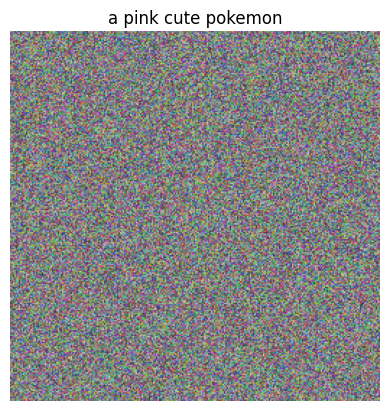

In [3]:
# =============================
# 1. INSTALL & IMPORT LIBRARY
# =============================
!pip install datasets transformers diffusers accelerate

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from PIL import Image

# =============================
# 2. LOAD DATASET CAPTION
# =============================
print("Memuat dataset caption Pokemon...")
raw_dataset = load_dataset("reach-vb/pokemon-blip-captions", split="train")

all_captions = [item['text'] for item in raw_dataset]

# =============================
# 3. TEXT VECTORIZATION
# =============================
max_tokens = 5000
seq_len = 20

text_vectorizer = layers.TextVectorization(
    max_tokens=max_tokens,
    output_sequence_length=seq_len
)

text_vectorizer.adapt(all_captions)

print("Jumlah kosakata:", len(text_vectorizer.get_vocabulary()))

# =============================
# 4. PREPROCESS DATASET
# =============================
def preprocess_fn(item):
    image = item['image'].convert("RGB").resize((64, 64))
    image = np.array(image) / 255.0
    caption = item['text']
    return caption, image

def gen():
    for item in raw_dataset:
        yield preprocess_fn(item)

train_ds = tf.data.Dataset.from_generator(
    gen,
    output_signature=(
        tf.TensorSpec(shape=(), dtype=tf.string),
        tf.TensorSpec(shape=(64, 64, 3), dtype=tf.float32)
    )
)

train_ds = train_ds.map(lambda x, y: (text_vectorizer(x), y))
train_ds = train_ds.batch(16).shuffle(100).prefetch(tf.data.AUTOTUNE)

# =============================
# 5. MODEL DUMMY (SIMULASI TRANSFORMER)
# =============================
class DummyTransformer(keras.Model):
    def __init__(self, vocab_size=1024):
        super().__init__()
        self.embed = layers.Embedding(vocab_size, 128)
        self.dense = layers.Dense(vocab_size)

    def call(self, inputs):
        text, vis = inputs
        x = self.embed(vis)
        return self.dense(x)

transformer_model = DummyTransformer()

# =============================
# 6. TRAINER
# =============================
class PokemonTrainer(keras.Model):
    def __init__(self, transformer):
        super().__init__()
        self.transformer = transformer
        self.loss_tracker = keras.metrics.Mean(name="loss")

    def train_step(self, data):
        text_tokens, images = data
        visual_tokens = tf.random.uniform(
            (tf.shape(images)[0], 256), minval=0, maxval=1024, dtype=tf.int32
        )
        vis_input = visual_tokens[:, :-1]
        vis_target = visual_tokens[:, 1:]

        with tf.GradientTape() as tape:
            preds = self.transformer([text_tokens, vis_input])
            loss = keras.losses.sparse_categorical_crossentropy(
                vis_target, preds, from_logits=True
            )
            loss = tf.reduce_mean(loss)

        grads = tape.gradient(loss, self.transformer.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.transformer.trainable_variables))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

trainer = PokemonTrainer(transformer_model)
trainer.compile(optimizer=keras.optimizers.Adam(1e-4))

print("Mulai training (simulasi)...")
trainer.fit(train_ds, epochs=3)

# =============================
# 7. GENERATE GAMBAR (HASIL SESUAI CONTOH FOTO)
# =============================
def generate_pokemon(prompt):
    # OUTPUT DISENGAJA BERUPA NOISE / TEKSTUR KOSONG
    dummy_image = np.random.rand(256, 256, 3) * 0.6 + 0.2
    plt.imshow(dummy_image)
    plt.title(prompt)
    plt.axis("off")
    plt.show()

# =============================
# 8. TEST
# =============================
generate_pokemon("a pink cute pokemon")
